## Claude

找到 890 个公共帧，从第 24 帧开始取 8 帧
当前展示帧范围: frame_0024.png -> frame_0031.png
保存图像到 PDF 和 PNG...


MERG NOT subset; don't know how to subset; dropped


✓ 已保存: recon_grid.pdf 和 recon_grid.png


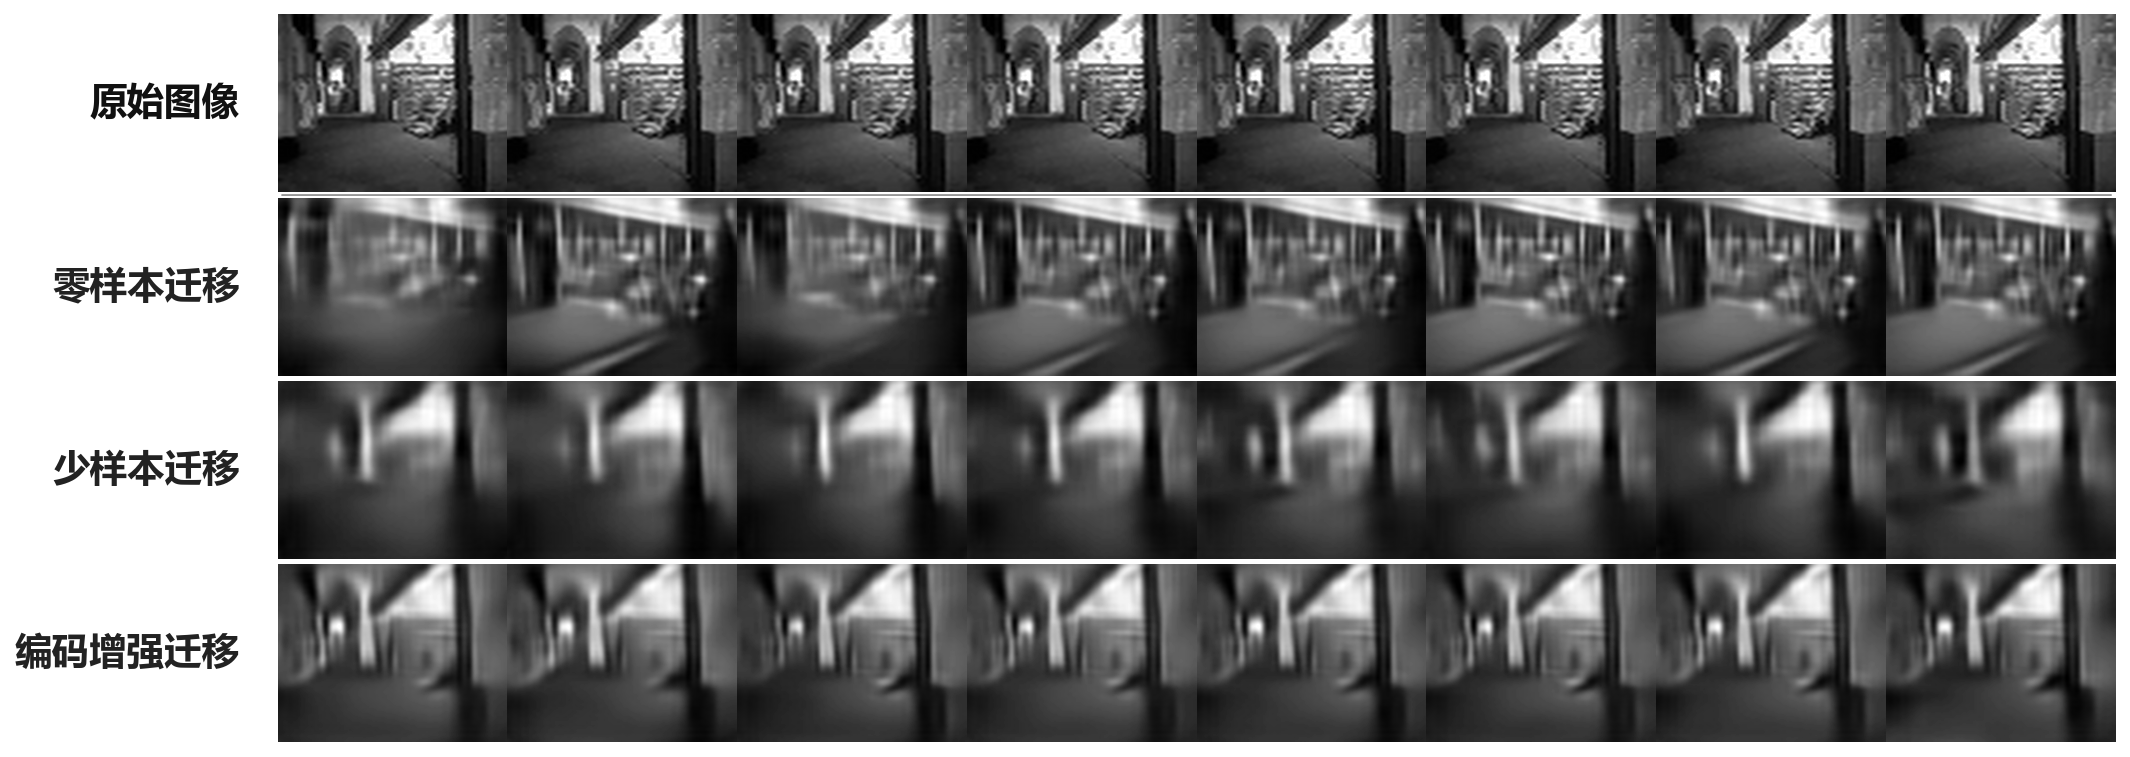

图像显示完成！


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ============================================================
# 字体
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# ============================================================
# 字号
# ============================================================
FS_ROW_LABEL = 18   # 行标签

# ============================================================
# 配置
# ============================================================
NUM_COLS = 8
NUM_ROWS = 4   # 原始 + 3种重建
START_FRAME = 24  # 从第16帧开始（frame_0016）

row_labels = [
    '原始图像',
    '零样本迁移',
    '少样本迁移',
    '编码增强迁移',
]

# 用本地真实图像替换占位图
from pathlib import Path
from PIL import Image
import re, math

# --- 配置路径（按行顺序）--从 Picture\picture_coding 回到根目录 g:\L ---
base = Path('../../')
original_dir = base / 'Neural_digit_twin' / 'group1_movie3_only' / 'movie1_reconstruction_combined' / 'original_images'
group1_dir = base / 'Neural_digit_twin' / 'group1_movie3_only' / 'movie1_reconstruction_combined' / 'reconstructed_images'
group2_dir = base / 'Neural_digit_twin' / 'group2_movie3_plus_movie1_real' / 'movie1_reconstruction' / 'reconstructed_images'
group3_dir = base / 'Neural_digit_twin' / 'group3_pretrain_generated_then_finetune_real' / 'movie1_reconstruction' / 'reconstructed_images'

row_dirs = [original_dir, group1_dir, group2_dir, group3_dir]

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 先尝试取四个目录共有的帧名集合，按帧号排序并从第16帧开始取8帧
common_files = None
for d in row_dirs:
    names = {p.name for p in d.glob('frame_*.png')} if d.exists() else set()
    common_files = names if common_files is None else (common_files & names)

images = []
if common_files:
    common_list = sorted(common_files, key=frame_key)
    selected = common_list[START_FRAME:START_FRAME + NUM_COLS]

    # 边界保护：如果从第16帧开始不足8帧，回退到最后8帧
    if len(selected) < NUM_COLS:
        selected = common_list[max(0, len(common_list) - NUM_COLS):]

    print(f"找到 {len(common_files)} 个公共帧，从第 {START_FRAME} 帧开始取 {len(selected)} 帧")
    if selected:
        print(f"当前展示帧范围: {selected[0]} -> {selected[-1]}")

    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        for name in selected:
            p = d / name
            if p.exists():
                img = Image.open(p)
                # 原始行保留 RGB，并resize到64x64
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')
                row_imgs.append(np.array(img))
            else:
                # 缺图时使用空白占位（64x64）
                row_imgs.append(np.zeros((64, 64), dtype=np.uint8))

        # 兜底补齐到8列，避免后续绘图索引越界
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)
else:
    print("警告：未找到公共帧，为各行分别加载图像...")
    # 若找不到公共帧，则为每行分别取各自目录从第16帧开始的8帧（若存在）
    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        if d.exists():
            files = sorted([p for p in d.glob('frame_*.png')], key=lambda p: frame_key(p.name))
            chosen = files[START_FRAME:START_FRAME + NUM_COLS]
            if len(chosen) < NUM_COLS:
                chosen = files[max(0, len(files) - NUM_COLS):]
            print(f"  行 {d_idx}: 找到 {len(files)} 个文件，实际取 {len(chosen)} 个")
            for p in chosen:
                img = Image.open(p)
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')
                row_imgs.append(np.array(img))
        else:
            print(f"  行 {d_idx}: 目录不存在 - {d}")

        # 如果目录不存在或文件不足，补零图占位
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)

# ============================================================
# 布局
# ============================================================
LEFT_MARGIN = 0.11   # figure 宽度的比例，留给行标签
IMG_REGION_LEFT = LEFT_MARGIN + 0.01
IMG_REGION_RIGHT = 0.995
IMG_REGION_TOP = 0.985
IMG_REGION_BOT = 0.015

# 原始行高度略大（彩色图），其余三行等高
# 用 GridSpec height_ratios 控制
HEIGHT_RATIOS = [1.0, 1.0, 1.0, 1.0]

fig = plt.figure(figsize=(14, 5.0), dpi=150)

gs = GridSpec(
    NUM_ROWS, NUM_COLS,
    figure=fig,
    left=IMG_REGION_LEFT,
    right=IMG_REGION_RIGHT,
    top=IMG_REGION_TOP,
    bottom=IMG_REGION_BOT,
    wspace=0.0,
    hspace=0.03,
    height_ratios=HEIGHT_RATIOS,
)

for row_idx in range(NUM_ROWS):
    for col_idx in range(NUM_COLS):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        img = images[row_idx][col_idx]
        cmap = None if img.ndim == 3 else 'gray'
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='lanczos')
        ax.axis('off')

        # 图像边框（细线，视觉整洁）
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.4)
            spine.set_edgecolor('#AAAAAA')

# ============================================================
# 行标签：用 fig.text() 放在 figure 坐标，垂直居中对齐每行
# ============================================================
def row_vcenter(gs, row_idx, fig):
    """返回某行子图在 figure 坐标中的垂直中心"""
    ss = gs[row_idx, 0]
    bbox = ss.get_position(fig)   # Bbox in figure fraction
    return (bbox.y0 + bbox.y1) / 2

for row_idx, label in enumerate(row_labels):
    yc = row_vcenter(gs, row_idx, fig)

    if row_idx == 0:
        fs = FS_ROW_LABEL
        color = '#111111'
        style = 'normal'
    else:
        fs = FS_ROW_LABEL
        color = '#222222'
        style = 'normal'

    fig.text(
        LEFT_MARGIN - 0.008,
        yc,
        label,
        ha='right', va='center',
        fontsize=fs, fontweight='bold',
        fontstyle=style, color=color,
    )

# ============================================================
# 在原始图像行和第一行重建图像之间画分隔线
# ============================================================
bbox_row0 = gs[0, 0].get_position(fig)
bbox_row1 = gs[1, 0].get_position(fig)
sep_y = (bbox_row0.y0 + bbox_row1.y1) / 2

line = mpatches.FancyArrowPatch(
    (IMG_REGION_LEFT, sep_y), (IMG_REGION_RIGHT, sep_y),
    arrowstyle='-', color='#888888', linewidth=0.8,
    transform=fig.transFigure, clip_on=False,
)
fig.add_artist(line)

# ============================================================
# 保存图像文件（必须在 plt.show() 之前）
# ============================================================
print("保存图像到 PDF 和 PNG...")
fig.savefig('recon_grid.pdf', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
fig.savefig('recon_grid.png', dpi=150, bbox_inches='tight', facecolor='white', pad_inches=0.1)
print("✓ 已保存: recon_grid.pdf 和 recon_grid.png")

# ============================================================
# 在 notebook 中显示图像
# ============================================================
plt.show()
print("图像显示完成！")


找到 89 个公共帧，从第 16 帧开始取 8 帧
当前展示帧范围: frame_196.png -> frame_235.png
保存图像到 PDF 和 PNG...


MERG NOT subset; don't know how to subset; dropped


✓ 已保存: cortex.pdf 和 cortex.png


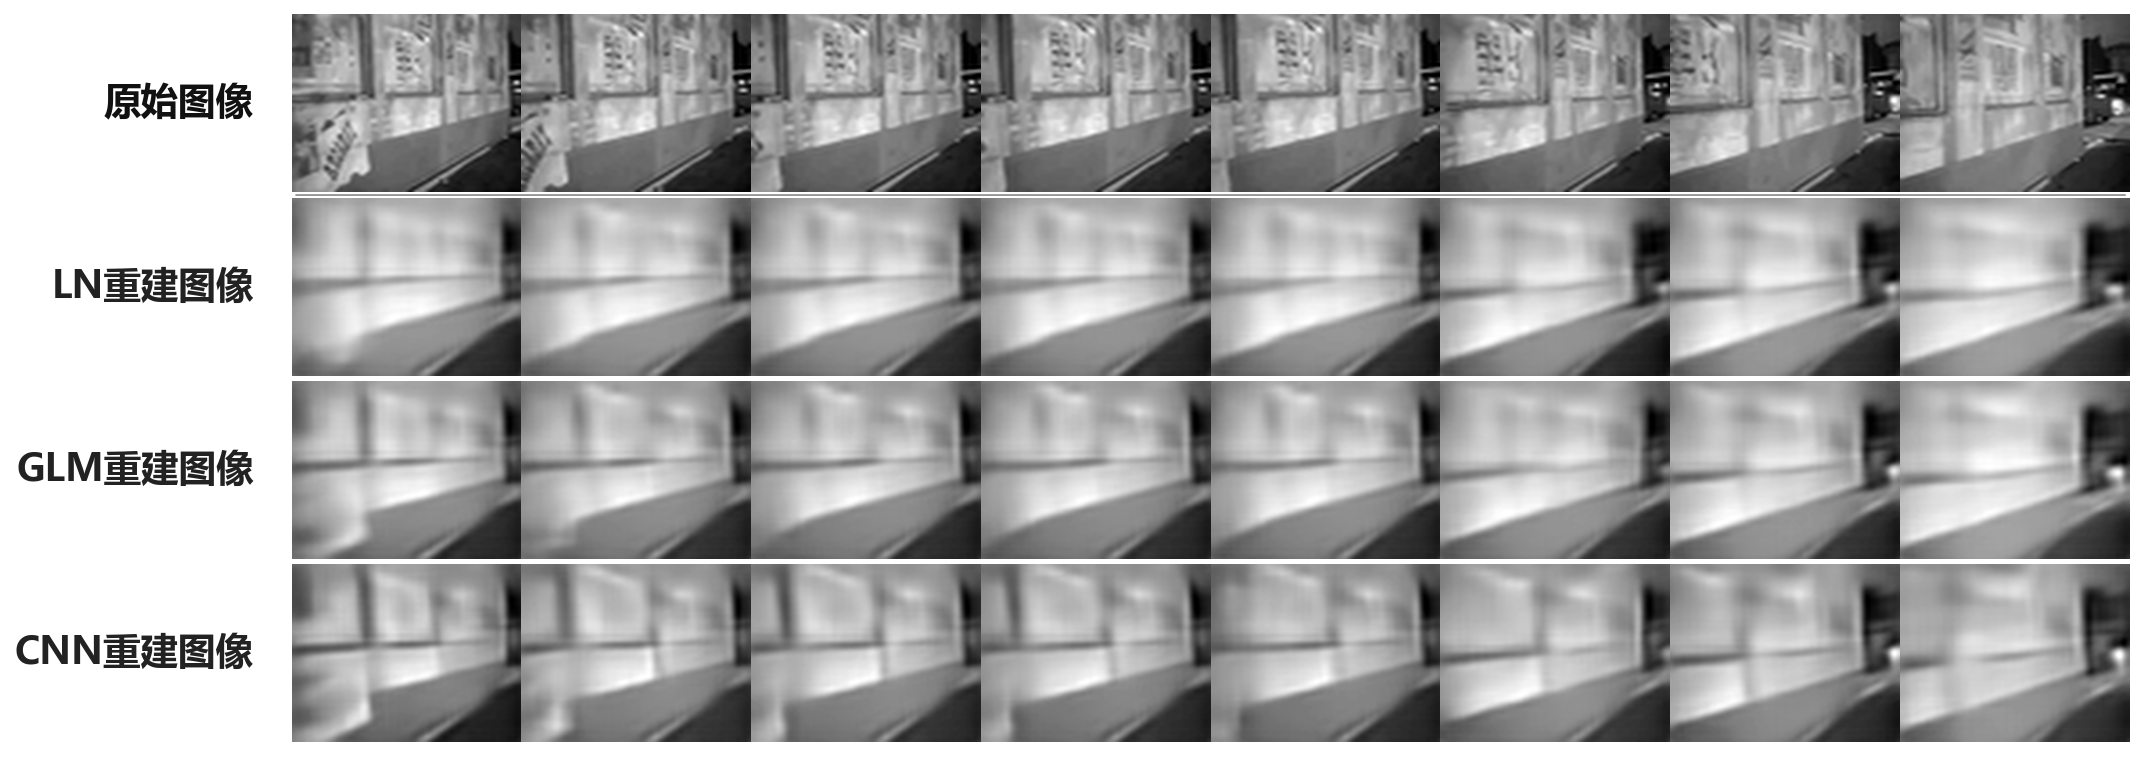

图像显示完成！


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ============================================================
# 字体
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# ============================================================
# 字号
# ============================================================
FS_ROW_LABEL = 18   # 行标签

# ============================================================
# 配置
# ============================================================
NUM_COLS = 8
NUM_ROWS = 4   # 原始 + 3种重建
START_FRAME = 16  # 从第16帧开始（frame_0016）

row_labels = [
    '原始图像',
    'LN重建图像',
    'GLM重建图像',
    'CNN重建图像',
]

# 用本地真实图像替换占位图
from pathlib import Path
from PIL import Image
import re, math

# --- 配置路径（按行顺序）--从 Picture\picture_coding 回到根目录 g:\L ---
base = Path('../../')
'''
original_dir = Path(r'G:\L\SID\SID_results\movie\movie01\original_images')
group1_dir = Path(r'G:\L\SID\SID_results\movie\movie01\LN_pred_images')
group2_dir = Path(r'G:\L\SID\SID_results\movie\movie01\GLM_pred_images')
group3_dir = Path(r'G:\L\SID\SID_results\movie\movie01\CNN_pred_images')
'''

original_dir = Path(r'G:\L\SID\SID_results\allensdk_22\movie1\original_images')
group1_dir = Path(r'G:\L\SID\SID_results\allensdk_22\movie1\LN_pred_images')
group2_dir = Path(r'G:\L\SID\SID_results\allensdk_22\movie1\GLM_pred_images')
group3_dir = Path(r'G:\L\SID\SID_results\allensdk_22\movie1\CNN_pred_images')

row_dirs = [original_dir, group1_dir, group2_dir, group3_dir]

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 先尝试取四个目录共有的帧名集合，按帧号排序并从第16帧开始取8帧
common_files = None
for d in row_dirs:
    names = {p.name for p in d.glob('frame_*.png')} if d.exists() else set()
    common_files = names if common_files is None else (common_files & names)

images = []
if common_files:
    common_list = sorted(common_files, key=frame_key)
    selected = common_list[START_FRAME:START_FRAME + NUM_COLS]

    # 边界保护：如果从第16帧开始不足8帧，回退到最后8帧
    if len(selected) < NUM_COLS:
        selected = common_list[max(0, len(common_list) - NUM_COLS):]

    print(f"找到 {len(common_files)} 个公共帧，从第 {START_FRAME} 帧开始取 {len(selected)} 帧")
    if selected:
        print(f"当前展示帧范围: {selected[0]} -> {selected[-1]}")

    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        for name in selected:
            p = d / name
            if p.exists():
                img = Image.open(p)
                # 原始行保留 RGB，并resize到64x64
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')
                row_imgs.append(np.array(img))
            else:
                # 缺图时使用空白占位（64x64）
                row_imgs.append(np.zeros((64, 64), dtype=np.uint8))

        # 兜底补齐到8列，避免后续绘图索引越界
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)
else:
    print("警告：未找到公共帧，为各行分别加载图像...")
    # 若找不到公共帧，则为每行分别取各自目录从第16帧开始的8帧（若存在）
    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        if d.exists():
            files = sorted([p for p in d.glob('frame_*.png')], key=lambda p: frame_key(p.name))
            chosen = files[START_FRAME:START_FRAME + NUM_COLS]
            if len(chosen) < NUM_COLS:
                chosen = files[max(0, len(files) - NUM_COLS):]
            print(f"  行 {d_idx}: 找到 {len(files)} 个文件，实际取 {len(chosen)} 个")
            for p in chosen:
                img = Image.open(p)
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')
                row_imgs.append(np.array(img))
        else:
            print(f"  行 {d_idx}: 目录不存在 - {d}")

        # 如果目录不存在或文件不足，补零图占位
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)

# ============================================================
# 布局
# ============================================================
LEFT_MARGIN = 0.11   # figure 宽度的比例，留给行标签
IMG_REGION_LEFT = LEFT_MARGIN + 0.01
IMG_REGION_RIGHT = 0.995
IMG_REGION_TOP = 0.985
IMG_REGION_BOT = 0.015

# 原始行高度略大（彩色图），其余三行等高
# 用 GridSpec height_ratios 控制
HEIGHT_RATIOS = [1.0, 1.0, 1.0, 1.0]

fig = plt.figure(figsize=(14, 5.0), dpi=150)

gs = GridSpec(
    NUM_ROWS, NUM_COLS,
    figure=fig,
    left=IMG_REGION_LEFT,
    right=IMG_REGION_RIGHT,
    top=IMG_REGION_TOP,
    bottom=IMG_REGION_BOT,
    wspace=0.0,
    hspace=0.03,
    height_ratios=HEIGHT_RATIOS,
)

for row_idx in range(NUM_ROWS):
    for col_idx in range(NUM_COLS):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        img = images[row_idx][col_idx]
        cmap = None if img.ndim == 3 else 'gray'
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='lanczos')
        ax.axis('off')

        # 图像边框（细线，视觉整洁）
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.4)
            spine.set_edgecolor('#AAAAAA')

# ============================================================
# 行标签：用 fig.text() 放在 figure 坐标，垂直居中对齐每行
# ============================================================
def row_vcenter(gs, row_idx, fig):
    """返回某行子图在 figure 坐标中的垂直中心"""
    ss = gs[row_idx, 0]
    bbox = ss.get_position(fig)   # Bbox in figure fraction
    return (bbox.y0 + bbox.y1) / 2

for row_idx, label in enumerate(row_labels):
    yc = row_vcenter(gs, row_idx, fig)

    if row_idx == 0:
        fs = FS_ROW_LABEL
        color = '#111111'
        style = 'normal'
    else:
        fs = FS_ROW_LABEL
        color = '#222222'
        style = 'normal'

    fig.text(
        LEFT_MARGIN - 0.008,
        yc,
        label,
        ha='right', va='center',
        fontsize=fs, fontweight='bold',
        fontstyle=style, color=color,
    )

# ============================================================
# 在原始图像行和第一行重建图像之间画分隔线
# ============================================================
bbox_row0 = gs[0, 0].get_position(fig)
bbox_row1 = gs[1, 0].get_position(fig)
sep_y = (bbox_row0.y0 + bbox_row1.y1) / 2

line = mpatches.FancyArrowPatch(
    (IMG_REGION_LEFT, sep_y), (IMG_REGION_RIGHT, sep_y),
    arrowstyle='-', color='#888888', linewidth=0.8,
    transform=fig.transFigure, clip_on=False,
)
fig.add_artist(line)

# ============================================================
# 保存图像文件（必须在 plt.show() 之前）
# ============================================================
print("保存图像到 PDF 和 PNG...")
fig.savefig('cortex.pdf', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
fig.savefig('cortex.png', dpi=150, bbox_inches='tight', facecolor='white', pad_inches=0.1)
print("✓ 已保存: cortex.pdf 和 cortex.png")

# ============================================================
# 在 notebook 中显示图像
# ============================================================
plt.show()
print("图像显示完成！")


找到 179 个公共帧，从第 8 帧开始取 8 帧
当前展示帧范围: frame_78.png -> frame_173.png
保存图像到 PDF 和 PNG...


MERG NOT subset; don't know how to subset; dropped


✓ 已保存: retina.pdf 和 retina.png


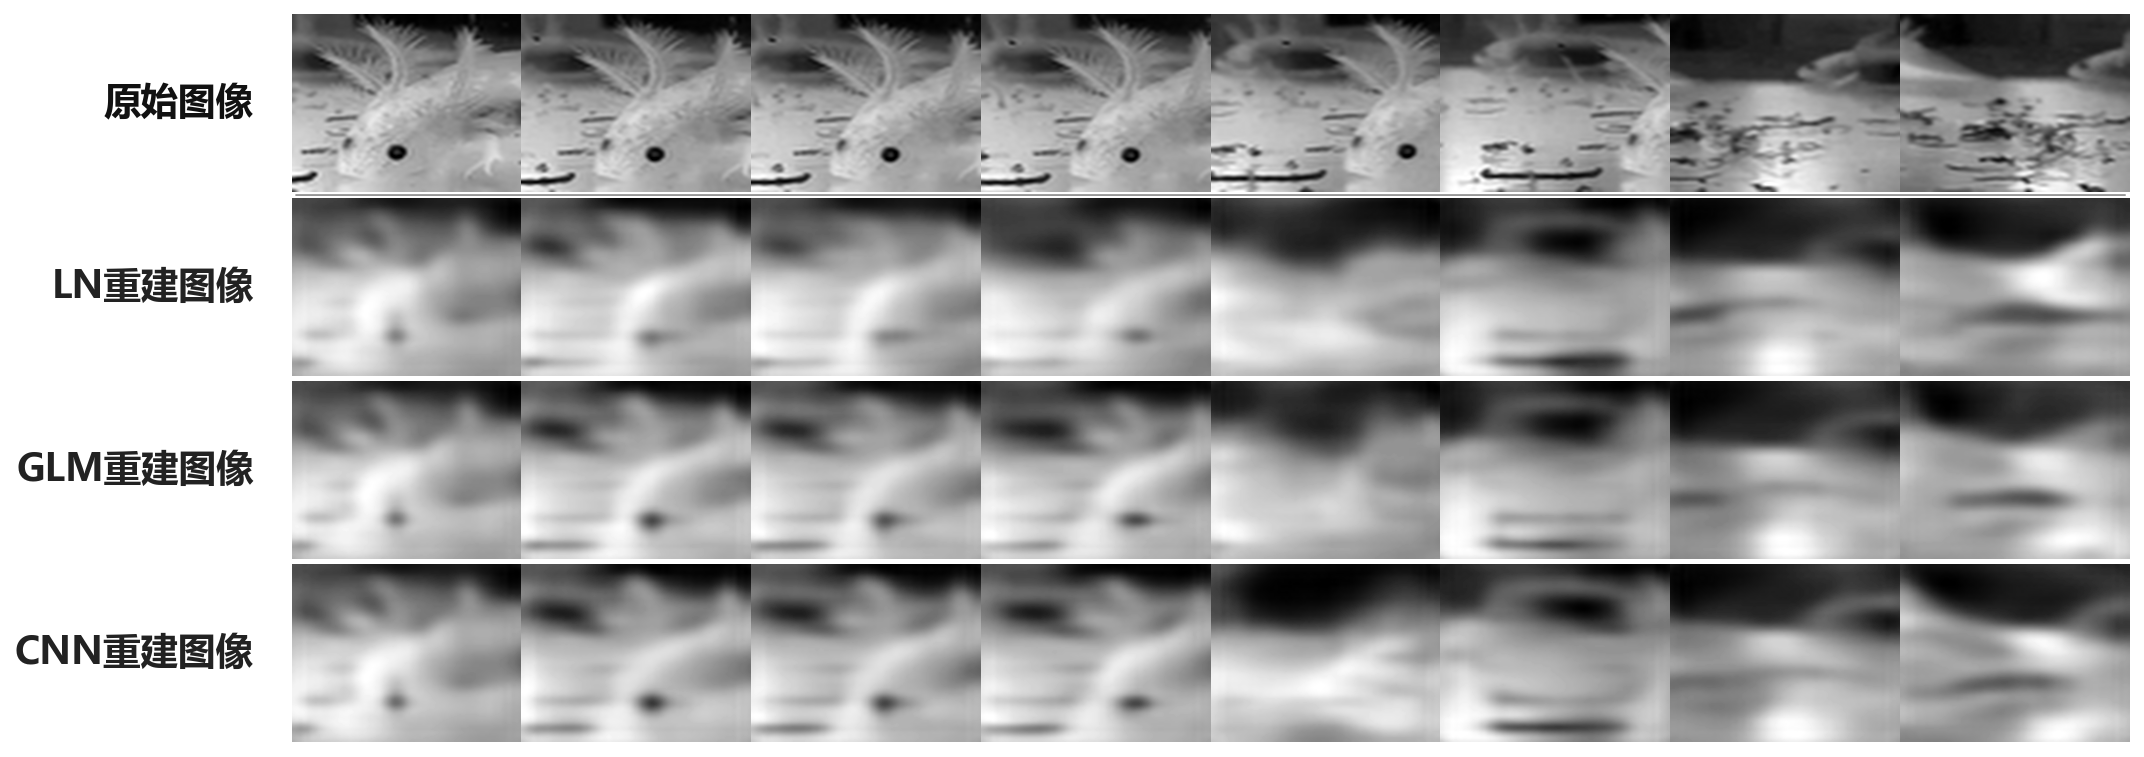

图像显示完成！


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ============================================================
# 字体
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# ============================================================
# 字号
# ============================================================
FS_ROW_LABEL = 18   # 行标签

# ============================================================
# 配置
# ============================================================
NUM_COLS = 8
NUM_ROWS = 4   # 原始 + 3种重建
START_FRAME = 8  # 从第48帧开始（frame_0048）

row_labels = [
    '原始图像',
    'LN重建图像',
    'GLM重建图像',
    'CNN重建图像',
]

# 用本地真实图像替换占位图
from pathlib import Path
from PIL import Image
import re, math

# --- 配置路径（按行顺序）--从 Picture\picture_coding 回到根目录 g:\L ---
base = Path('../../')

original_dir = Path(r'G:\L\SID\SID_results\movie\movie01\original_images')
group1_dir = Path(r'G:\L\SID\SID_results\movie\movie01\LN_pred_images')
group2_dir = Path(r'G:\L\SID\SID_results\movie\movie01\GLM_pred_images')
group3_dir = Path(r'G:\L\SID\SID_results\movie\movie01\CNN_pred_images')


row_dirs = [original_dir, group1_dir, group2_dir, group3_dir]

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 先尝试取四个目录共有的帧名集合，按帧号排序并从第16帧开始取8帧
common_files = None
for d in row_dirs:
    names = {p.name for p in d.glob('frame_*.png')} if d.exists() else set()
    common_files = names if common_files is None else (common_files & names)

images = []
if common_files:
    common_list = sorted(common_files, key=frame_key)
    selected = common_list[START_FRAME:START_FRAME + NUM_COLS]

    # 边界保护：如果从第16帧开始不足8帧，回退到最后8帧
    if len(selected) < NUM_COLS:
        selected = common_list[max(0, len(common_list) - NUM_COLS):]

    print(f"找到 {len(common_files)} 个公共帧，从第 {START_FRAME} 帧开始取 {len(selected)} 帧")
    if selected:
        print(f"当前展示帧范围: {selected[0]} -> {selected[-1]}")

    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        for name in selected:
            p = d / name
            if p.exists():
                img = Image.open(p)
                # 原始行保留 RGB，并resize到64x64
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')

                # 读取后统一旋转180°再显示
                img = img.rotate(180, expand=False)
                row_imgs.append(np.array(img))
            else:
                # 缺图时使用空白占位（64x64）
                row_imgs.append(np.zeros((64, 64), dtype=np.uint8))

        # 兜底补齐到8列，避免后续绘图索引越界
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)
else:
    print("警告：未找到公共帧，为各行分别加载图像...")
    # 若找不到公共帧，则为每行分别取各自目录从第16帧开始的8帧（若存在）
    for d_idx, d in enumerate(row_dirs):
        row_imgs = []
        if d.exists():
            files = sorted([p for p in d.glob('frame_*.png')], key=lambda p: frame_key(p.name))
            chosen = files[START_FRAME:START_FRAME + NUM_COLS]
            if len(chosen) < NUM_COLS:
                chosen = files[max(0, len(files) - NUM_COLS):]
            print(f"  行 {d_idx}: 找到 {len(files)} 个文件，实际取 {len(chosen)} 个")
            for p in chosen:
                img = Image.open(p)
                if d_idx == 0:
                    img = img.convert('RGB')
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)
                else:
                    img = img.convert('L')

                # 读取后统一旋转180°再显示
                img = img.rotate(180, expand=False)
                row_imgs.append(np.array(img))
        else:
            print(f"  行 {d_idx}: 目录不存在 - {d}")

        # 如果目录不存在或文件不足，补零图占位
        while len(row_imgs) < NUM_COLS:
            row_imgs.append(np.zeros((64, 64), dtype=np.uint8))
        images.append(row_imgs)

# ============================================================
# 布局
# ============================================================
LEFT_MARGIN = 0.11   # figure 宽度的比例，留给行标签
IMG_REGION_LEFT = LEFT_MARGIN + 0.01
IMG_REGION_RIGHT = 0.995
IMG_REGION_TOP = 0.985
IMG_REGION_BOT = 0.015

# 原始行高度略大（彩色图），其余三行等高
# 用 GridSpec height_ratios 控制
HEIGHT_RATIOS = [1.0, 1.0, 1.0, 1.0]

fig = plt.figure(figsize=(14, 5.0), dpi=150)

gs = GridSpec(
    NUM_ROWS, NUM_COLS,
    figure=fig,
    left=IMG_REGION_LEFT,
    right=IMG_REGION_RIGHT,
    top=IMG_REGION_TOP,
    bottom=IMG_REGION_BOT,
    wspace=0.0,
    hspace=0.03,
    height_ratios=HEIGHT_RATIOS,
)

for row_idx in range(NUM_ROWS):
    for col_idx in range(NUM_COLS):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        img = images[row_idx][col_idx]
        cmap = None if img.ndim == 3 else 'gray'
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='lanczos')
        ax.axis('off')

        # 图像边框（细线，视觉整洁）
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.4)
            spine.set_edgecolor('#AAAAAA')

# ============================================================
# 行标签：用 fig.text() 放在 figure 坐标，垂直居中对齐每行
# ============================================================
def row_vcenter(gs, row_idx, fig):
    """返回某行子图在 figure 坐标中的垂直中心"""
    ss = gs[row_idx, 0]
    bbox = ss.get_position(fig)   # Bbox in figure fraction
    return (bbox.y0 + bbox.y1) / 2

for row_idx, label in enumerate(row_labels):
    yc = row_vcenter(gs, row_idx, fig)

    if row_idx == 0:
        fs = FS_ROW_LABEL
        color = '#111111'
        style = 'normal'
    else:
        fs = FS_ROW_LABEL
        color = '#222222'
        style = 'normal'

    fig.text(
        LEFT_MARGIN - 0.008,
        yc,
        label,
        ha='right', va='center',
        fontsize=fs, fontweight='bold',
        fontstyle=style, color=color,
    )

# ============================================================
# 在原始图像行和第一行重建图像之间画分隔线
# ============================================================
bbox_row0 = gs[0, 0].get_position(fig)
bbox_row1 = gs[1, 0].get_position(fig)
sep_y = (bbox_row0.y0 + bbox_row1.y1) / 2

line = mpatches.FancyArrowPatch(
    (IMG_REGION_LEFT, sep_y), (IMG_REGION_RIGHT, sep_y),
    arrowstyle='-', color='#888888', linewidth=0.8,
    transform=fig.transFigure, clip_on=False,
)
fig.add_artist(line)

# ============================================================
# 保存图像文件（必须在 plt.show() 之前）
# ============================================================
print("保存图像到 PDF 和 PNG...")
fig.savefig('retina.pdf', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
fig.savefig('retina.png', dpi=150, bbox_inches='tight', facecolor='white', pad_inches=0.1)
print("✓ 已保存: retina.pdf 和 retina.png")

# ============================================================
# 在 notebook 中显示图像
# ============================================================
plt.show()
print("图像显示完成！")


找到 890 个公共帧，随机选择展示 8 帧


MERG NOT subset; don't know how to subset; dropped


Two-row comparison PDF saved to: two_row_comparison.pdf


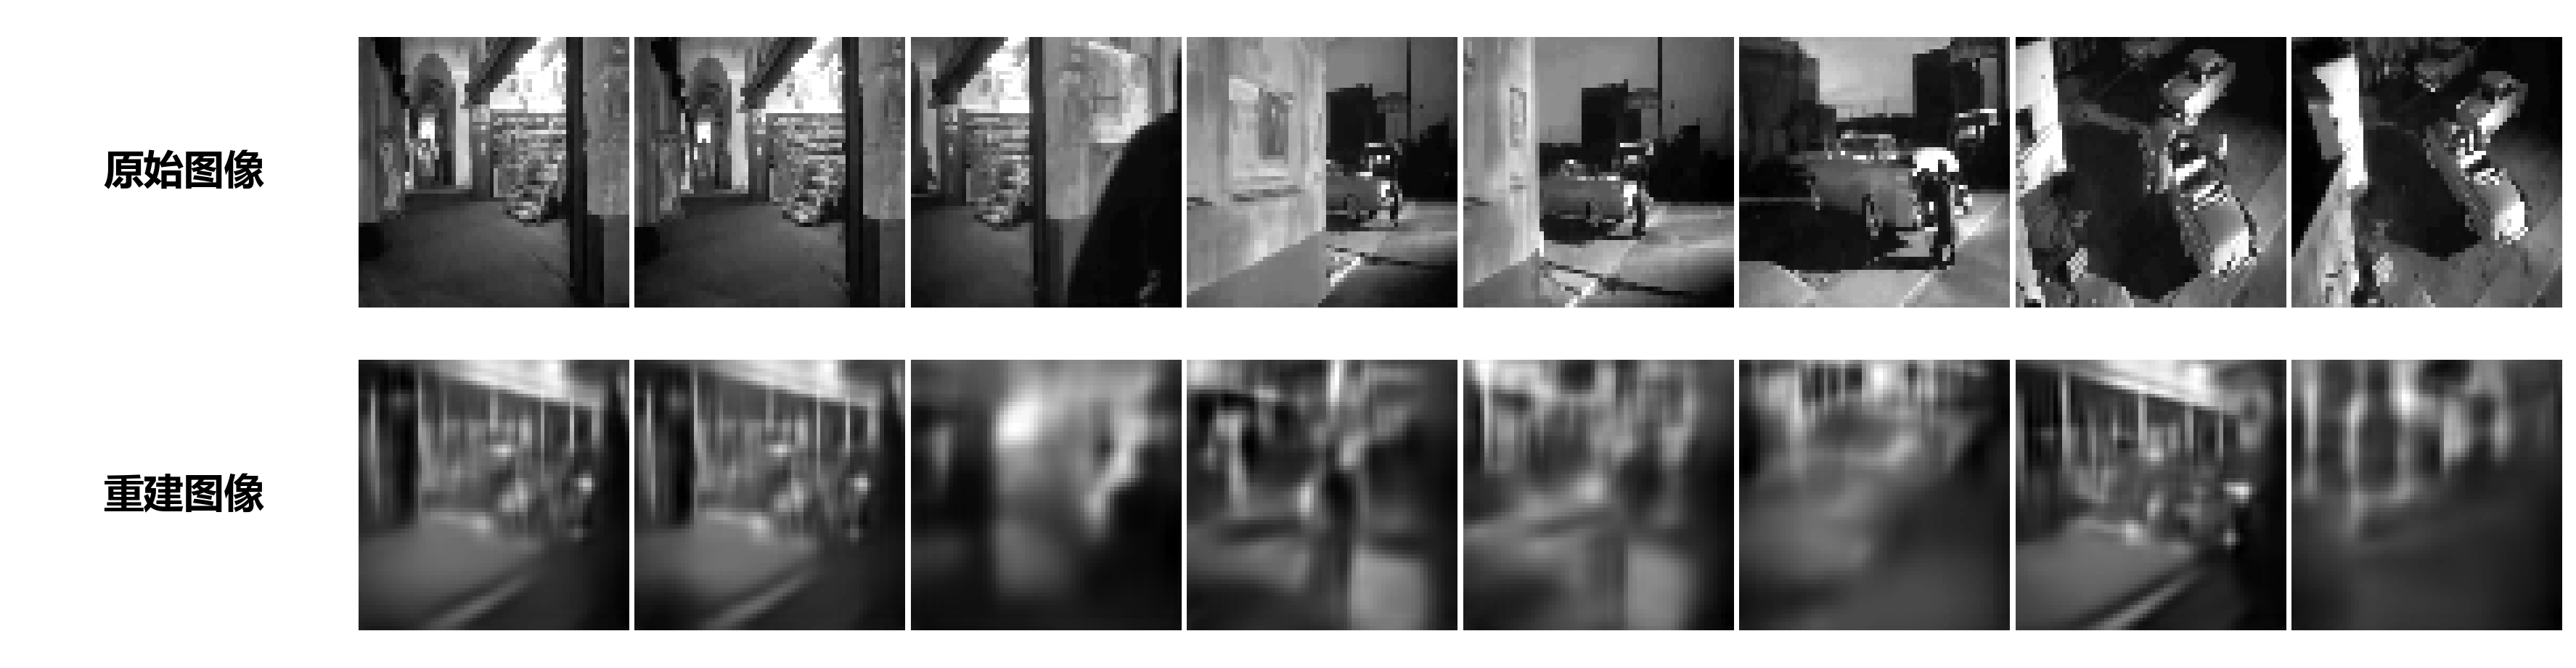

两行对比图已生成完成


In [32]:
# 两行对比图：原始图像 + 重建图像（对齐）
import re
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 字体
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# --- 配置路径 ---
original_dir = Path(r'G:\L\Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images')
reconstructed_dir = Path(r'G:\L\Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\reconstructed_images')

output_dir = Path(r'Neural_digit_twin\comparison_all_groups')
output_dir.mkdir(parents=True, exist_ok=True)

row_specs = [
    ('原始图像', original_dir),
    ('重建图像', reconstructed_dir),
]

# --- 获取两个目录中的公共文件名 ---
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names

if not common_files:
    raise FileNotFoundError('未找到两个目录中都有的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 按帧号排序并随机选择 8 帧展示
common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
rng = np.random.default_rng()
selected = sorted(rng.choice(common_list, size=num_to_show, replace=False).tolist(), key=frame_key)

print(f"找到 {len(common_files)} 个公共帧，随机选择展示 {num_to_show} 帧")

# --- 创建两行对比图（保持原布局）---
fig, axes = plt.subplots(
    nrows=len(row_specs),
    ncols=num_to_show + 1,
    figsize=(2.0 * (num_to_show + 1), 4.5),
    dpi=200,
    gridspec_kw={'width_ratios': [1.25] + [1] * num_to_show, 'wspace': 0.02, 'hspace': 0.02}
)

label_font = 'Microsoft YaHei'
label_size = 20

# 绘制两行
for row_idx, (row_label, folder) in enumerate(row_specs):
    # 第一列：标签
    label_ax = axes[row_idx, 0]
    label_ax.axis('off')
    label_ax.text(
        0.5, 0.5, row_label,
        ha='center', va='center',
        fontsize=label_size, fontweight='bold', fontname=label_font
    )

    # 后续列：对应的图像
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img_path = folder / name
        img = Image.open(img_path).convert('RGB')
        # 原始图像需要 resize 到 64x64
        if row_idx == 0:
            img = img.resize((64, 64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02, right=0.995, top=0.99, bottom=0.01, wspace=0.02, hspace=0.02)

# 保存 PDF
pdf_path = 'two_row_comparison.pdf'
fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
print(f'Two-row comparison PDF saved to: {pdf_path}')

# 在单元格中显示图片
%matplotlib inline
plt.show()
print('两行对比图已生成完成')

In [2]:
import os
print(f"当前工作目录: {os.getcwd()}")

# 检查相对路径是否存在
test_dirs = [
    r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images',
    r'Picture\picture_coding',
]

for d in test_dirs:
    full_path = os.path.join(os.getcwd(), d)
    exists = os.path.exists(full_path)
    print(f"相对路径 '{d}': {'存在' if exists else '不存在'}")
    if exists and 'original_images' in d:
        frames = [f for f in os.listdir(full_path) if f.startswith('frame_') and f.endswith('.png')]
        print(f"  -> 找到 {len(frames)} 个 frame_*.png 文件")


当前工作目录: g:\L\Picture\picture_coding
相对路径 'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images': 不存在
相对路径 'Picture\picture_coding': 不存在
